# <div align="center"><b> Exploración de datos </b></div>

<div align="right">

<!-- [![Binder](http://mybinder.org/badge.svg)](https://mybinder.org/) -->
[![nbviewer](https://img.shields.io/badge/render-nbviewer-orange?logo=Jupyter)](https://nbviewer.org)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com)

</div>

* * *

<style>
/* Limitar la altura de las celdas de salida en html */
.jp-OutputArea.jp-Cell-outputArea {
    max-height: 500px;
}
</style>

🛻 <em><font color='MediumSeaGreen'>  Instalaciones: </font></em> 🛻

Este notebook utiliza [Poetry](https://python-poetry.org/) para la gestión de dependencias.
Primero instala Poetry siguiendo las instrucciones de su [documentación oficial](https://python-poetry.org/docs/#installation).
Luego ejecuta el siguiente comando para instalar las dependencias necesarias y activar el entorno virtual:

- Bash:
```bash
poetry install
eval $(poetry env activate)
```

- PowerShell:
```powershell
poetry install
Invoke-Expression (poetry env activate)
```

<!-- Descargar archivos adicionales:
!gdown https://drive.google.com/drive/folders/1UBZ8PEbtmiWMGkULu7GAt3VhUpeTy9l7?usp=sharing --folder -->

✋ <em><font color='DodgerBlue'>Importaciones:</font></em> ✋

In [1]:
# Recarga automática de módulos en Jupyter Notebook
%reload_ext autoreload
%autoreload 2

import sys, json

from loguru import logger as LOGGER
from modulo_ia.config import config as CONFIG
from modulo_apps.database_comunication.mongodb_client import mongodb as MONGODB

import PIL

import modulo_ia.dataset as DatasetProcessor

import modulo_apps.s3_comunication.procesador_s3 as ProcesadorS3
import modulo_apps.labeling.visualizador_coco_dataset as VisualizadorCOCODataset
import modulo_apps.labeling.procesador_anotaciones_mongodb as ProcesadorAnotacionesMongoDB

2025-09-13 10:43:58.318 | INFO     | modulo_apps.config:<module>:18 - Directorio de configuración raíz: E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-apps
2025-09-13 10:43:58.320 | INFO     | modulo_apps.config:<module>:22 - Variables de entorno cargadas desde .env.dev.


2025-09-13 10:43:58.332 | INFO     | modulo_ia.config:<module>:19 - Directorio de configuración raíz: E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA
2025-09-13 10:43:58.335 | INFO     | modulo_ia.config:<module>:23 - Variables de entorno cargadas desde .env.dev.


e:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔧 <em><font color='tomato'>Configuraciones:</font></em> 🔧


In [ ]:
LOGGER.remove()
LOGGER.add(sys.stderr, level="INFO")
PIL.Image.MAX_IMAGE_PIXELS = None

# Parámetros
SHOULD_PROCESS_DATASET = False  # Descarga el dataset completo

RAW_DATA_FOLDER = CONFIG.folders.raw_data_folder
EXTERNAL_DATA_FOLDER = CONFIG.folders.external_data_folder
INTERIM_DATA_FOLDER = CONFIG.folders.interim_data_folder
PROCESSED_DATA_FOLDER = CONFIG.folders.processed_data_folder
DATA_FOLDER = CONFIG.folders.data_folder

DATASET_NAME = CONFIG.names.palm_dataset_name
DATASET_VERSION = CONFIG.versions.v11
DATASET_IDENTIFIER = f"{DATASET_NAME}_{DATASET_VERSION}"

DATASET_RAW_NAME = DATASET_IDENTIFIER
DATASET_RAW_PATH = RAW_DATA_FOLDER / DATASET_RAW_NAME

<div align="center">✨Datos del proyecto:✨</div>

<p></p>

<div align="center">

| **Subtitulo**   | Exploración de los datos                                                                                                        |
| --------------- | -------------------------------------------------------------------------------------------------------------------------------------- |
| **Descrpción**  | <small>Notebook de exploración de los datos</small>                                                                    |

</div>

# Chequeo de conexiones

In [3]:
# Chequeo de conexión a MinIO
LOGGER.info("Chequeando conexión a MinIO...")
ProcesadorS3.test_connection()

# Chequeo de conexión a MongoDB
LOGGER.info("Chequeando conexión a MongoDB...")
MONGODB.command("ping")  # Verifica la conexión a MongoDB
LOGGER.success("Conexión a MongoDB verificada correctamente.")

2025-09-13 10:44:10.469 | INFO     | __main__:<module>:2 - Chequeando conexión a MinIO...
2025-09-13 10:44:10.476 | SUCCESS  | modulo_apps.s3_comunication.procesador_s3:test_connection:39 - Conexión exitosa a S3 y acceso al bucket 'picudo-rojo-bucket' verificado.
2025-09-13 10:44:10.476 | INFO     | __main__:<module>:6 - Chequeando conexión a MongoDB...
2025-09-13 10:44:10.486 | SUCCESS  | __main__:<module>:8 - Conexión a MongoDB verificada correctamente.


## Descarga del dataset

In [5]:
if SHOULD_PROCESS_DATASET:
    LOGGER.info("Descargando el dataset completo...")
    DatasetProcessor.download_patches_raw_dataset(output_folder=DATASET_RAW_PATH)

if DATASET_RAW_PATH.exists():
    LOGGER.info("Dataset ya descargado. Procesando dataset...")
    dataset_metrics = DatasetProcessor.get_dataset_metrics(
        dataset_path=DATASET_RAW_PATH, dataset_name=DATASET_RAW_NAME, dataset_format=DatasetProcessor.DatasetFormat.COCO
    )
    dataset_stats = DatasetProcessor.get_dataset_stats(
        dataset_path=DATASET_RAW_PATH, dataset_name=DATASET_RAW_NAME, dataset_format=DatasetProcessor.DatasetFormat.COCO
    )
    LOGGER.info(f"Metricas del dataset:\n {json.dumps(dataset_metrics, indent=2)}")
    LOGGER.info(f"Estadísticas del dataset:\n {json.dumps(dataset_stats, indent=2)}")

2025-09-13 10:44:39.562 | INFO     | __main__:<module>:2 - Descargando el dataset completo...
Descargando parches: 1288parche [04:10,  5.14parche/s]
2025-09-13 10:49:02.862 | INFO     | __main__:<module>:6 - Dataset ya descargado. Procesando dataset...


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
 100% |███████████████| 1288/1288 [5.7s elapsed, 0s remaining, 206.9 samples/s]      
 100% |███████████████| 1288/1288 [5.5s elapsed, 0s remaining, 197.1 samples/s]      


2025-09-13 10:49:14.344 | INFO     | __main__:<module>:13 - Metricas del dataset:
 {
  "total_images_count": 1288,
  "total_images_with_detections": 1288,
  "total_images_without_detections": 0,
  "class_count": {
    "palmera-sana": 8403,
    "palmera-muerta": 280,
    "palmera-infectada": 170,
    "palmera-exterminada": 191
  }
}
2025-09-13 10:49:14.345 | INFO     | __main__:<module>:14 - Estadísticas del dataset:
 {
  "samples_count": 1288,
  "samples_bytes": 2802954,
  "samples_size": "2.7MB",
  "media_bytes": 0,
  "media_size": "0.0B",
  "total_bytes": 2802954,
  "total_size": "2.7MB"
}


## Validación de etiquetado

NameError: name 'image_path' is not defined

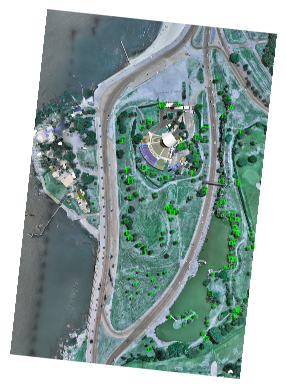

In [ ]:
# # patches/GroupID1/teatroDeVerano_20240110_mavic_5c/teatroDeVerano_20240110_mavic_5c_patch_11.jpg
# image_name = "teatroDeVerano_20240110_mavic_5c"
# group_id = "GroupID1"
# img_path = ProcesadorS3.download_image_from_s3(image_name, group_id)
# coco_annotations_path = ProcesadorAnotacionesMongoDB.download_annotations_as_coco_from_mongodb(
#     images_names=[image_name]
# )
# VisualizadorCOCODataset.show_annotated_image_path(
#     img_path,
#     coco_annotations_path,
#     image_name=image_name,
#     use_layoutparser=False,
#     should_download_annotated_image=True
# )